Step 1: Read in, unzip, and look at the first 5 rows of the circRNA-seq



In [17]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133319/suppl/GSE133319%5FmiRNA%2Dexp%2Etxt%2Egz #miRNA




--2026-05-15 16:21:03--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133319/suppl/GSE133319%5FmiRNA%2Dexp%2Etxt%2Egz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22871 (22K) [application/x-gzip]
Saving to: ‘GSE133319_miRNA-exp.txt.gz’

GSE133319_miRNA-exp 100%[===================>]  22.33K  --.-KB/s    in 0.03s   

2026-05-15 16:21:03 (784 KB/s) - ‘GSE133319_miRNA-exp.txt.gz’ saved [22871/22871]



In [18]:
!gzip -d GSE133319_miRNA-exp.txt.gz


gzip: GSE133319_miRNA-exp.txt already exists; do you wish to overwrite (y or n)? n
	not overwritten


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("GSE133319_miRNA-exp.txt", sep="\t")

df = df.set_index("tracking_id")

df.head()

,con-3,con-4,con-5,HV-2,HV-4,HV-6
tracking_id,,,,,,
hsa-let-7a-5p,22333.4960,21728.5421,20919.3983,19611.6439,17593.2820,17391.6754
hsa-let-7a-3p,252.1360,206.0698,180.4718,96.8227,87.9214,134.2871
hsa-let-7a-2-3p,1.8816,2.0583,2.2852,1.6084,2.4112,1.7618
hsa-let-7b-5p,3627.3357,2702.5488,2553.9710,3817.5158,2335.6516,2600.9146
hsa-let-7b-3p,45.9819,36.8150,39.7952,34.4830,21.2893,23.2947


Trying the analysis again with PyDeSEQ2:

LLM prompt: using Deseq2 in python, perform a DEG analysis comparing control groups (con3, con4, and con5) versus infected groups (HV2, HV4, HV6). Obtain the log2FC, the FDRs, and filter based on |log2FC| > 1 and FDR < 0.05.

In [21]:
!pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

# PyDESeq2 needs RAW counts (integers), not log-transformed RPM
counts = df.T

counts = counts.astype(int)

# Metadata dataframe
metadata = pd.DataFrame({
    'condition': ['control', 'control', 'control', 'infected', 'infected', 'infected']
}, index=counts.index)

# Run DESeq2
dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
dds.deseq2()

# Extract results
stat_res = DeseqStats(dds, contrast=["condition", "infected", "control"])
stat_res.summary()

results_deseq = stat_res.results_df
sig = results_deseq[(results_deseq['padj'] < 0.05) & (results_deseq['log2FoldChange'].abs() > 1)]
print(f"Significant DEGs: {len(sig)}")

sig.head()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_2692/834651725.py:17: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.54 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.75 seconds.

Fitting LFCs...
... done in 0.53 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition infected vs control
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
tracking_id                                                                    
hsa-let-7a-5p     19783.301568       -0.077340  0.197647 -0.391303  0.695573   
hsa-let-7a-3p       155.391041       -0.811682  0.278218 -2.917436  0.003529   
hsa-let-7a-2-3p       1.516403       -0.152887  1.442446 -0.105991  0.915589   
hsa-let-7b-5p      2897.631782        0.148345  0.221480  0.669787  0.502994   
hsa-let-7b-3p        32.248474       -0.454883  0.375917 -1.210062  0.226255   
...                        ...             ...       ...       ...       ...   
hsa-miR-8089          0.000000             NaN       NaN       NaN       NaN   
hsa-miR-8485          0.000000             NaN       NaN       NaN       NaN   
hsa-miR-9500          0.000000             NaN       NaN       NaN       NaN   
hsa-miR-548bb-5p      0.000000             NaN      

... done in 0.96 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
tracking_id,,,,,,
hsa-miR-199a-5p,97.140757,-1.206635,0.392424,-3.074827,0.002106,0.048870
hsa-miR-30c-5p,2393.736901,-1.154884,0.271733,-4.250061,0.000021,0.001085
hsa-miR-7-5p,2413.332004,1.144060,0.293064,3.903790,0.000095,0.003495
hsa-miR-221-3p,5721.336280,-1.006450,0.288110,-3.493284,0.000477,0.013836
hsa-miR-146a-5p,963.392441,1.023238,0.261798,3.908494,0.000093,0.003495


In [22]:
sig.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
tracking_id,,,,,,
hsa-miR-199a-5p,97.140757,-1.206635,0.392424,-3.074827,0.002106,0.048870
hsa-miR-30c-5p,2393.736901,-1.154884,0.271733,-4.250061,0.000021,0.001085
hsa-miR-7-5p,2413.332004,1.144060,0.293064,3.903790,0.000095,0.003495
hsa-miR-221-3p,5721.336280,-1.006450,0.288110,-3.493284,0.000477,0.013836
hsa-miR-146a-5p,963.392441,1.023238,0.261798,3.908494,0.000093,0.003495


In [23]:
sig.shape #Gives us 97 DEGs which is a lot closer to the 70 DEGs that the authors identified...

(15, 6)

Make volcano

In [24]:
pvs   = results_deseq['pvalue'].values
logFC = results_deseq['log2FoldChange'].values

print("Total missing p-values:", np.isnan(pvs).sum())

Total missing p-values: 1957


Remove those 0/NA p-values

In [25]:
valid  = ~np.isnan(pvs)
pvs_valid   = pvs[valid]
logFC_valid = logFC[valid]

In [26]:
fdrs_valid = results_deseq['padj'].values[valid]

# P-value cutoff at FDR=0.05
p_fdr005     = pvs_valid[fdrs_valid < 0.05].max()
p_cutoff     = p_fdr005
logFC_cutoff = 1
print("P-value at FDR=0.05:", p_fdr005)

P-value at FDR=0.05: 0.002166647121905049


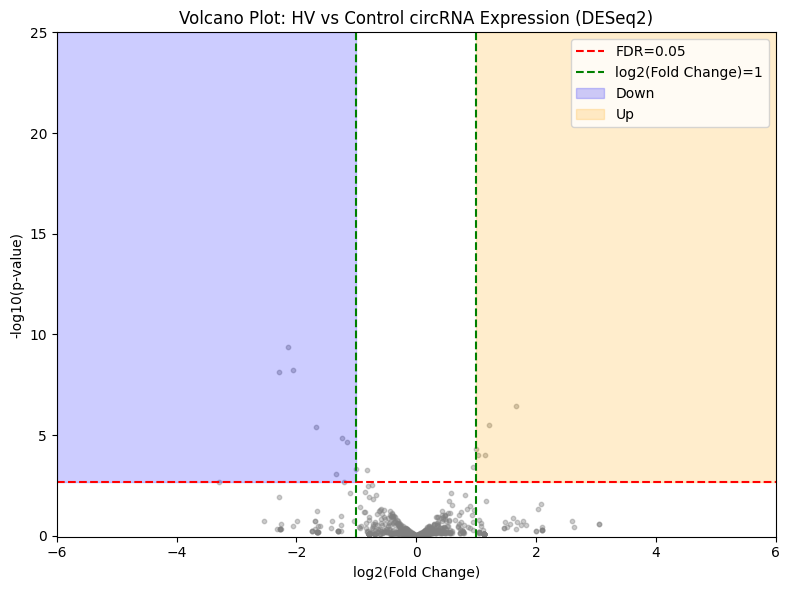

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(logFC_valid, -np.log10(pvs_valid), alpha=0.4, c='grey', s=10)
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(p-value)')
plt.axhline(-np.log10(p_cutoff), color='r', linestyle='--', label='FDR=0.05')
plt.axvline( logFC_cutoff,       color='g', linestyle='--', label='log2(Fold Change)=1')
plt.axvline(-logFC_cutoff,       color='g', linestyle='--')
plt.fill_between([-6, -1], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='blue',   label='Down')
plt.fill_between([ 1,  6], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='orange', label='Up')
plt.xlim(-6, 6)
plt.ylim(-0.05, 25)
plt.legend()
plt.title('Volcano Plot: HV vs Control circRNA Expression (DESeq2)')
plt.tight_layout()
plt.show()



In [28]:
#LLM prompt: tell me the names of the DEGs, and then tell me the names of the upregulated and downregulated ones
print(f"Total significant circRNAs: {len(sig)}")
print(f"Upregulated   (log2FC >  1): {len(sig[sig['log2FoldChange'] >  1])}")
print(f"Downregulated (log2FC < -1): {len(sig[sig['log2FoldChange'] < -1])}")

#Pretty good, the authors identified 70 DEGs, 65 up and 5 down so this is somewhat consistent. Only difference is we used pydeseq2 and they used edgeR.

Total significant circRNAs: 15
Upregulated   (log2FC >  1): 5
Downregulated (log2FC < -1): 10


TF analysis


In [29]:
!pip install gseapy -q

import pandas as pd
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt


In [30]:
deg_mirna = sig.index.tolist()

print(f"Total miRNA DEGs: {len(deg_mirna)}")
print(deg_mirna[:10])

Total miRNA DEGs: 15
['hsa-miR-199a-5p', 'hsa-miR-30c-5p', 'hsa-miR-7-5p', 'hsa-miR-221-3p', 'hsa-miR-146a-5p', 'hsa-miR-186-5p', 'hsa-miR-379-3p', 'hsa-miR-337-3p', 'hsa-miR-411-3p', 'hsa-miR-654-3p']


Need to convert these to real gene names somehow --> LLM: converse hsa-miR form to actual gene names for the deg_miRNAs

In [31]:
tf_results_mirna = gp.enrichr(
    gene_list=deg_mirna,
    gene_sets=[
        'ChEA_2022',
        'ENCODE_TF_ChIP-seq_2015',
        'TF_Perturbations_Followed_by_Expression'
    ],
    organism='human',
    outdir=None
)

tf_results_mirna.results.head(5)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


Nothing popping up, so we will read in the miRNA database csv and try to make a graph

In [32]:
mirtarbase = pd.read_csv('mir2tf.csv')

# Count how many times each TF appears
tf_counts = mirtarbase['Target'].value_counts()

print(tf_counts.head(20))

Target
RELA      8
NFKB1     7
PBX2      7
MYC       5
HIF1A     5
HNF4A     4
SPI1      4
JUN       4
EGR1      3
MYCN      3
BRCA1     3
MITF      3
SRF       3
TP53      3
STAT3     2
ZBTB16    2
TWIST1    2
SOX2      2
PPARA     2
FOSL1     2
Name: count, dtype: int64


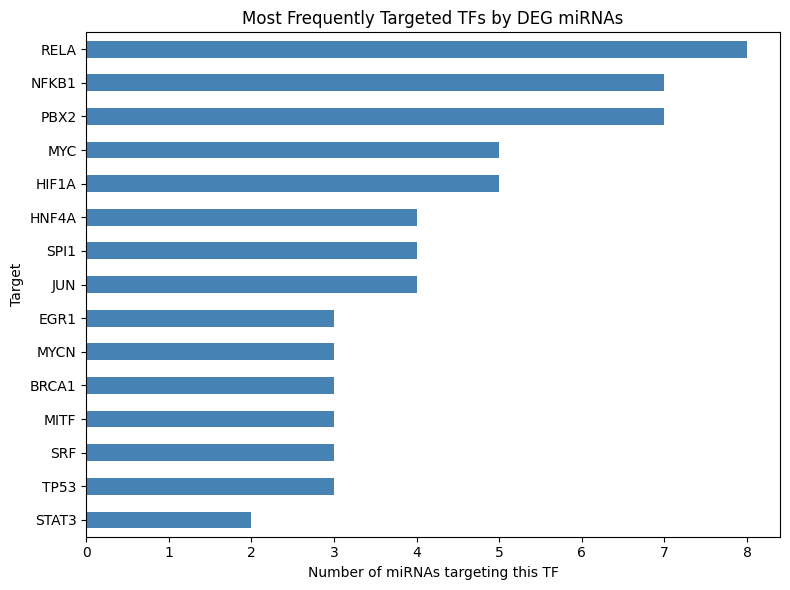

In [33]:
tf_counts.head(15).plot(
    kind='barh',
    figsize=(8, 6),
    color='steelblue'
)
plt.xlabel('Number of miRNAs targeting this TF')
plt.title('Most Frequently Targeted TFs by DEG miRNAs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
#LLM Prompt: write me code in Python that takes the miRNA data as the input and outputs me a list of the top 10 TFs arranged from lowest adj. P value to highest.

top_tfs = mirtarbase['Target'].value_counts().index.tolist()

print(top_tfs)


['RELA', 'NFKB1', 'PBX2', 'MYC', 'HIF1A', 'HNF4A', 'SPI1', 'JUN', 'EGR1', 'MYCN', 'BRCA1', 'MITF', 'SRF', 'TP53', 'STAT3', 'ZBTB16', 'TWIST1', 'SOX2', 'PPARA', 'FOSL1', 'REST', 'CEBPA', 'EGR3', 'BANP', 'ATOH8', 'ATF3', 'BRD4', 'ILF3', 'ILF2', 'IL1B', 'HOXD10', 'HOXB7', 'FOXP3', 'GATA2', 'HDAC1', 'ESR1', 'ETS1', 'EPAS1', 'EZH2', 'CBFB', 'CTNNB1', 'EED', 'NR3C2', 'RELB', 'RBPJ', 'PSMD9', 'RBBP5', 'KMT2A', 'NFE2L2', 'NFKB2', 'RUNX1', 'SRSF1', 'RUNX1T1', 'RUNX3', 'SNAI2', 'TLR2', 'TGFB1', 'TCF4', 'TNFSF12']
